Import Libraries

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm

In [27]:
#Load data
data = pd.read_csv("m5_merged.csv")
data['date'] = pd.to_datetime(data['date'])
data = data.sort_values(['item_id','store_id','date'])
data.head()

/tmp/ipykernel_5554/2069480524.py:2: DtypeWarning: Columns (14,15,16,17) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("m5_merged.csv")


,id,item_id,dept_id,cat_id,store_id,state_id,d,demand,date,wm_yr_wk,...,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,sell_price
1612,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_1,3.0,2011-01-29,11101,...,1,2011,NaN,NaN,NaN,NaN,0,0,0,NaN
3455,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_2,0.0,2011-01-30,11101,...,1,2011,NaN,NaN,NaN,NaN,0,0,0,NaN
5298,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_3,0.0,2011-01-31,11101,...,1,2011,NaN,NaN,NaN,NaN,0,0,0,NaN
7141,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_4,1.0,2011-02-01,11101,...,2,2011,NaN,NaN,NaN,NaN,1,1,0,NaN
8984,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_5,4.0,2011-02-02,11101,...,2,2011,NaN,NaN,NaN,NaN,1,0,1,NaN


In [28]:
data.shape

(3577263, 22)

Handling missing values

In [29]:
# Price filling
data['price'] = data.groupby(['store_id','item_id'])['sell_price'].ffill().bfill()
data['price'] = data.groupby('item_id')['price'].transform(lambda x: x.fillna(x.median()))
data['price'] = data['price'].fillna(data['price'].median())

# Demand cleaning
data = data.dropna(subset=['demand'])
data = data[data['demand'] >= 0]

Feature Engineering

In [30]:
# Time features
data['month'] = data['date'].dt.month
data['weekday'] = data['date'].dt.weekday

# Event
data['event_flag'] = data['event_name_1'].notna().astype(int)

# SNAP
data['snap'] = data[['snap_CA','snap_TX','snap_WI']].max(axis=1)

# Lag features
data['lag_7'] = data.groupby(['item_id','store_id'])['demand'].shift(7)
data['rolling_mean_7'] = data.groupby(['item_id','store_id'])['demand'].shift(1).rolling(7).mean()

# Drop only required NaNs
data = data.dropna(subset=['lag_7','rolling_mean_7'])

# Log features
data['log_price'] = np.log(data['price'] + 1e-5)
data['log_demand'] = np.log1p(data['demand'])

#Price Signal
data['price_relative'] = data['price'] / data.groupby(['item_id','store_id'])['price'].transform('mean')

Choose any one store and item

In [31]:
item = "FOODS_1_001"
store = "CA_1"
subset = data[(data['item_id'] == item) & (data['store_id'] == store)]

Elasticity Modelling

In [32]:
X = subset[['log_price','event_flag']]
X = sm.add_constant(X)

y = subset['log_demand']

model = sm.OLS(y, X).fit()
print(model.summary())

elasticity = -abs(model.params['log_price'])
print("Elasticity:", elasticity)

                            OLS Regression Results                            
Dep. Variable:             log_demand   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.8108
Date:                Wed, 08 Apr 2026   Prob (F-statistic):              0.368
Time:                        16:31:16   Log-Likelihood:                -1507.6
No. Observations:                1934   AIC:                             3019.
Df Residuals:                    1932   BIC:                             3030.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
log_price      0.1857      0.006     33.503      0.0

### **Prediction using ML**

In [33]:
data_model = data.copy()
data_model['item_code'] = data_model['item_id'].astype('category').cat.codes
data_model['item_avg_demand'] = data_model.groupby('item_id')['demand'].transform('mean')
data_model['store_code'] = data_model['store_id'].astype('category').cat.codes
features = [
    'price','month','weekday','lag_7','snap','price_relative', 'item_code','item_avg_demand','store_code'
]

In [34]:
X_ml = data_model[features]
y_ml = data_model['demand']

In [35]:
#time based splitting (data is already sorted)
split = int(len(X_ml) * 0.8)
X_train = X_ml.iloc[:split]
X_test = X_ml.iloc[split:]
y_train = y_ml.iloc[:split]
y_test = y_ml.iloc[split:]

Random Forest Model Training

In [36]:
rf = RandomForestRegressor(
    n_estimators=150,
    max_depth=12,
    min_samples_leaf=10,
    random_state=42
)
rf.fit(X_train, y_train)

RandomForestRegressor(max_depth=12, min_samples_leaf=10, n_estimators=150,
                      random_state=42)

In [37]:
preds = rf.predict(X_test)
print("MAE:", mean_absolute_error(y_test, preds))
print("R2:", r2_score(y_test, preds))

MAE: 0.4656421044649646
R2: 0.17696524457969953


Feature Importance

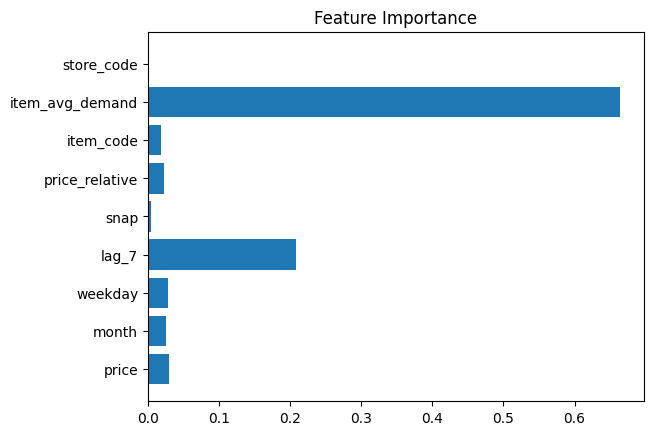

In [38]:
importance = rf.feature_importances_

plt.barh(features, importance)
plt.title("Feature Importance")
plt.show()

Optimization Function

In [39]:
def optimize_price(model, subset, features):

    if subset is None or len(subset) < 30:
        return None, None

    price_mean = subset['price'].mean()

    price_range = np.linspace(
        price_mean * 0.7,
        price_mean * 1.3,
        30
    )

    results = []

    for p in price_range:

        temp = pd.DataFrame({
            'price': [p],
            'month': [subset.iloc[-1]['month']],
            'weekday': [subset.iloc[-1]['weekday']],
            'lag_7': [subset.iloc[-1]['lag_7']],
            'snap': [subset.iloc[-1]['snap']],
            'price_relative': [p / price_mean],
            'item_code': [subset.iloc[-1]['item_code']],
            'item_avg_demand': [subset['demand'].mean()],
            'store_code': [subset.iloc[-1]['store_code']]
        })

        temp = temp[features]

        demand_pred = model.predict(temp)[0]

        demand_adj = demand_pred * np.exp(-0.8 * (p - price_mean) / price_mean)

        revenue = p * demand_adj

        results.append((p, revenue))

    df_rev = pd.DataFrame(results, columns=['price','revenue'])

    optimal = df_rev.loc[df_rev['revenue'].idxmax()]

    return df_rev, optimal

Run Optimization

For One Product Item

In [40]:
item = "FOODS_1_001"
store = "CA_1"

subset = data_model[
    (data_model['item_id'] == item) &
    (data_model['store_id'] == store)
]

df_rev, optimal = optimize_price(rf, subset, features)

print("Optimal Price:", optimal['price'])
print("Max Revenue:", optimal['revenue'])

Optimal Price: 7.895241379310344
Max Revenue: 13.93878580134862


In [41]:
print(df_rev.head(10))

      price    revenue
0  6.706000  12.258587
1  6.904207  12.413731
2  7.102414  12.815887
3  7.300621  13.290111
4  7.498828  13.492257
5  7.697034  13.673422
6  7.895241  13.938786
7  8.093448  12.745408
8  8.291655  13.043926
9  8.489862  12.183001


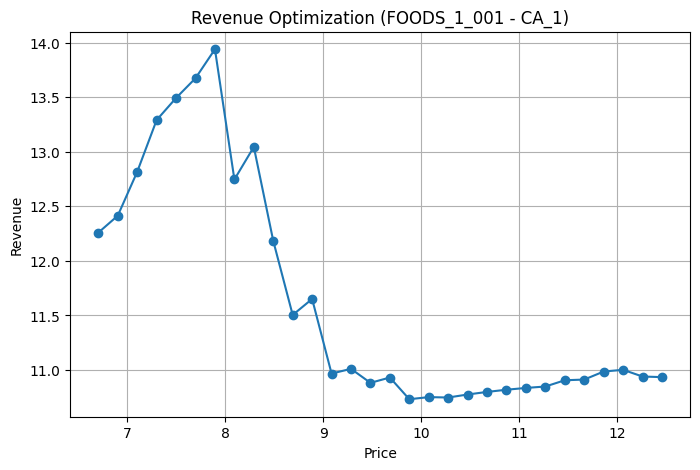

In [42]:
plt.figure(figsize=(8,5))
plt.plot(df_rev['price'], df_rev['revenue'], marker='o')
plt.xlabel("Price")
plt.ylabel("Revenue")
plt.title(f"Revenue Optimization ({item} - {store})")
plt.grid()
plt.show()

For multiple products

In [43]:
results_all = []

unique_items = data['item_id'].unique()
print(len(unique_items))

1843


In [44]:
stores = data['store_id'].unique()
for store in stores:
    for item in unique_items[:50]:
        subset = data_model[
            (data_model['item_id'] == item) &
            (data_model['store_id'] == store)
        ]
        if len(subset) < 50:
            continue
        df_rev, optimal = optimize_price(rf, subset, features)
        if optimal is not None:
            results_all.append({
                'item_id': item,
                'store_id': store,
                'optimal_price': optimal['price'],
                'expected_revenue': optimal['revenue']
            })
df_results = pd.DataFrame(results_all)
print(df_results.head())

       item_id store_id  optimal_price  expected_revenue
0  FOODS_1_001     CA_1       7.895241         13.938786
1  FOODS_1_002     CA_1       9.877310          6.657253
2  FOODS_1_003     CA_1       7.498828         13.180380
3  FOODS_1_004     CA_1       7.895241         91.688772
4  FOODS_1_005     CA_1      12.255793         30.751014


In [45]:
df_results

,item_id,store_id,optimal_price,expected_revenue
0,FOODS_1_001,CA_1,7.895241,13.938786
1,FOODS_1_002,CA_1,9.877310,6.657253
2,FOODS_1_003,CA_1,7.498828,13.180380
3,FOODS_1_004,CA_1,7.895241,91.688772
4,FOODS_1_005,CA_1,12.255793,30.751014
5,FOODS_1_006,CA_1,11.462966,18.310202
6,FOODS_1_008,CA_1,9.282690,4.576873
7,FOODS_1_009,CA_1,12.255793,10.585031
8,FOODS_1_010,CA_1,10.868345,3.856190
9,FOODS_1_011,CA_1,9.877310,6.496165


Top Products

In [46]:
df_results.sort_values(by='expected_revenue', ascending=False).head(10)

,item_id,store_id,optimal_price,expected_revenue
16,FOODS_1_018,CA_1,12.057586,139.338646
41,FOODS_1_043,CA_1,12.057586,112.738575
17,FOODS_1_019,CA_1,8.886276,103.594600
30,FOODS_1_032,CA_1,8.093448,93.142338
3,FOODS_1_004,CA_1,7.895241,91.688772
44,FOODS_1_046,CA_1,9.084483,86.923343
38,FOODS_1_040,CA_1,10.273724,39.685704
40,FOODS_1_042,CA_1,10.273724,39.454496
43,FOODS_1_045,CA_1,8.688069,39.291904
34,FOODS_1_036,CA_1,10.471931,37.739158


In [47]:
import pickle

with open("model.pkl", "wb") as f:
    pickle.dump(rf, f)

In [48]:
with open("features.pkl", "wb") as f:
    pickle.dump(features, f)

In [49]:
data['item_code'] = data['item_id'].astype('category').cat.codes
data['item_avg_demand'] = data.groupby('item_id')['demand'].transform('mean')
data['store_code'] = data['store_id'].astype('category').cat.codes

data.to_csv("data_processed.csv", index=False)